# YZ50 · Hafta 2 — micrograd: sıfırdan geri yayılım



In [ ]:
!pip install graphviz

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,
                 label="{ %s | data %.4f | grad %.4f }" % (getattr(n, 'label', ''), n.data, n.grad),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

---

# Görev 1 — `Value` sınıfı ve hesaplama grafiği

> *Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten
> Value'ları ve hangi işlemden çıktığını saklasın. Computation graph'i graphviz ile çizdir.*
> — video 19:09 – 32:10

Her `Value` dört şey tutar:

- `data` — sayının kendisi
- `grad` — çıktının bu düğüme göre türevi (şimdilik hep 0)
- `_prev` — bu değeri üreten çocuk düğümler
- `_op` — hangi işlemle üretildi



In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

### İleri geçiş: `L = (a·b + c)·f`

In [ ]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
L = d * f; L.label = 'L'

for v in [a, b, c, e, d, f, L]:
    kids = sorted(k.label for k in v._prev)
    print(f"{v.label:2} data={v.data:7.2f}  op={v._op or '(yaprak)':9} çocuklar={kids}")

a  data=   2.00  op=(yaprak)  çocuklar=[]
b  data=  -3.00  op=(yaprak)  çocuklar=[]
c  data=  10.00  op=(yaprak)  çocuklar=[]
e  data=  -6.00  op=*         çocuklar=['a', 'b']
d  data=   4.00  op=+         çocuklar=['c', 'e']
f  data=  -2.00  op=(yaprak)  çocuklar=[]
L  data=  -8.00  op=*         çocuklar=['d', 'f']


In [ ]:
!apt-get install -y graphviz
%pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


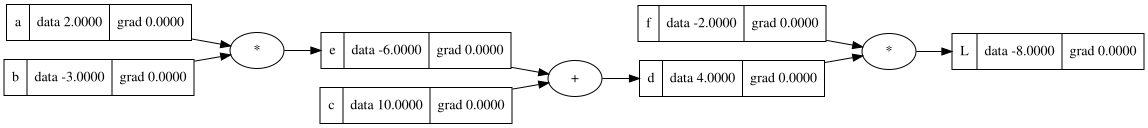

In [ ]:
draw_dot(L)

---

# Görev 2 — Gradyanları elle doldur



Grafiğin **sonundan başlayıp geriye** yürüyor, her düğümün `grad` alanını dolduruyoruz.
Doldurduğumuz şeyin tanımı hep aynı: **çıktının o düğüme göre türevi.**

Yürüyüş üç kuralla ilerler:

| İşlem | Kural | Neden |
|---|---|---|
| başlangıç | `L.grad = 1` | L'yi h artırırsan L h artar |
| toplama `d = e + c` | gradyanı **aynen dağıt** | yerel türev 1 |
| çarpma `L = d·f` | gradyanı **karşı çarpanla** çarp | yerel türev = diğer çarpanın değeri |

Hepsini birbirine bağlayan şey zincir kuralı: `dz/dx = (dz/dy)·(dy/dx)`. karpathy araba örneği


### 2.1 Basit İfade

In [ ]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
L = d * f; L.label = 'L'

#  backward'u elle başlatıyoruz
L.grad = 1.0

# L = d * f
d.grad = f.data * L.grad
f.grad = d.data * L.grad

# d = e + c
e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad

# e = a * b  -> çarpma
a.grad = b.data * e.grad
b.grad = a.data * e.grad

for v in [a, b, c, e, d, f, L]:
    print(f"{v.label:2} data={v.data:7.2f}  grad={v.grad:6.2f}")

a  data=   2.00  grad=  6.00
b  data=  -3.00  grad= -4.00
c  data=  10.00  grad= -2.00
e  data=  -6.00  grad= -2.00
d  data=   4.00  grad= -2.00
f  data=  -2.00  grad=  4.00
L  data=  -8.00  grad=  1.00


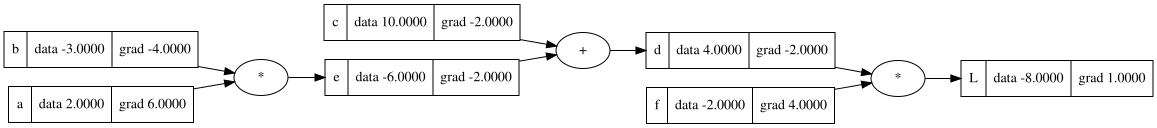

In [ ]:
draw_dot(L)

### 2.2 · Tek nöron ve `tanh`

Nöron modeli: girdiler `x`, ağırlıklar `w`, çarpımların toplamı + `bias`, sonra aktivasyon.
`tanh` girdiyi (−1, 1) aralığına yumuşakça sıkıştırır.

Geri yayılım için gereken tek şey yerel türevi: `d/dx tanh(x) = 1 − tanh(x)²`.
`tanh(n)` zaten çıktının kendisi olduğu için pratikte `n.grad = (1 − o.data²) · o.grad`.

`bias = 6.8813735870195432` özellikle seçilmiştir: `o = 0.7071` çıkar, karesi tam 0.5,
yani yerel türev **0.5** olur ve sayılar kafada takip edilebilir hale gelir.

In [ ]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        return out

In [ ]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
bias = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + bias; n.label = 'n'
o = n.tanh();        o.label = 'o'

#  backward'u elle başlatıyoruz
o.grad = 1.0

# o = tanh(n)  türevi = 1 - o^2
n.grad = (1 - o.data**2) * o.grad

# n = x1w1x2w2 + bias -> toplama: aynen dağıt
x1w1x2w2.grad = 1.0 * n.grad
bias.grad     = 1.0 * n.grad

# x1w1x2w2 = x1w1 + x2w2 -> toplama: aynen dağıt
x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad

# çarpma düğümleri: karşı çarpanla çarp
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

for v in [x1, x2, w1, w2, bias, x1w1, x2w2, x1w1x2w2, n, o]:
    print(f"{v.label:14} data={v.data:8.4f}  grad={v.grad:.4f}")

x1             data=  2.0000  grad=-1.5000
x2             data=  0.0000  grad=0.5000
w1             data= -3.0000  grad=1.0000
w2             data=  1.0000  grad=0.0000
b              data=  6.8814  grad=0.5000
x1*w1          data= -6.0000  grad=0.5000
x2*w2          data=  0.0000  grad=0.5000
x1*w1 + x2*w2  data= -6.0000  grad=0.5000
n              data=  0.8814  grad=0.5000
o              data=  0.7071  grad=1.0000


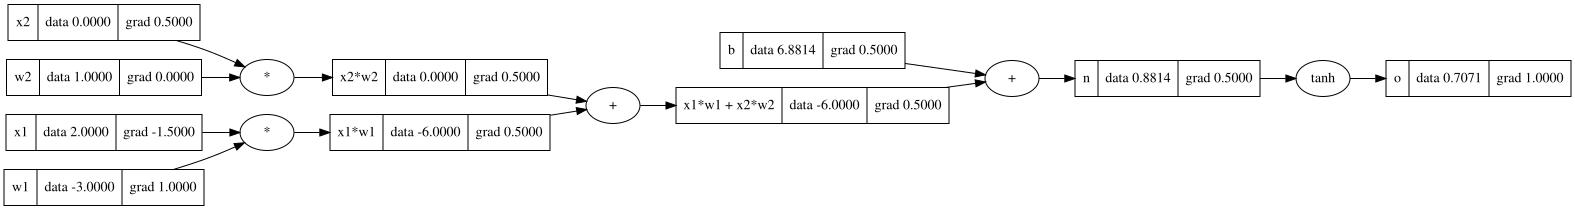

In [ ]:
draw_dot(o)

---

# Görev 3 — `backward()` metodu


**Neden `+=`, `=` değil?** Bir düğüm birden fazla yerde kullanılırsa (`b = a + a`),
iki `_backward` çağrısı da aynı nesneye yazar ve ikincisi birincinin üstüne biner.
Çok değişkenli zincir kuralı zaten şunu söyler: farklı yollardan gelen katkılar **toplanır**.
`grad`'ın 0'dan başlaması da tam bu yüzden.

In [ ]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad   # yerel türev = diğer çarpan
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad     # 1 - tanh²
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

### 3.1 · Doğrulama — basit ifade

Görev 2'de elle yazdığın 7 satırın yerine tek satır: `L.backward()`

In [ ]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
L = d * f; L.label = 'L'

L.backward()

elle = {'a': 6.0, 'b': -4.0, 'c': -2.0, 'e': -2.0, 'd': -2.0, 'f': 4.0, 'L': 1.0}
for v in [a, b, c, e, d, f, L]:
    ok = "OK" if abs(v.grad - elle[v.label]) < 1e-9 else "FARKLI"
    print(f"{v.label:2} data={v.data:7.2f}  grad={v.grad:6.2f}   elle={elle[v.label]:6.2f}  {ok}")

a  data=   2.00  grad=  6.00   elle=  6.00  OK
b  data=  -3.00  grad= -4.00   elle= -4.00  OK
c  data=  10.00  grad= -2.00   elle= -2.00  OK
e  data=  -6.00  grad= -2.00   elle= -2.00  OK
d  data=   4.00  grad= -2.00   elle= -2.00  OK
f  data=  -2.00  grad=  4.00   elle=  4.00  OK
L  data=  -8.00  grad=  1.00   elle=  1.00  OK


### 3.2 · Doğrulama — neuron

In [ ]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
bias = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + bias; n.label = 'n'
o = n.tanh();        o.label = 'o'

o.backward()

elle = {'x1': -1.5, 'x2': 0.5, 'w1': 1.0, 'w2': 0.0, 'b': 0.5,
        'x1*w1': 0.5, 'x2*w2': 0.5, 'x1*w1 + x2*w2': 0.5, 'n': 0.5, 'o': 1.0}
for v in [x1, x2, w1, w2, bias, x1w1, x2w2, x1w1x2w2, n, o]:
    ok = "OK" if abs(v.grad - elle[v.label]) < 1e-9 else "FARKLI"
    print(f"{v.label:14} data={v.data:8.4f}  grad={v.grad:7.4f}   elle={elle[v.label]:6.2f}  {ok}")

x1             data=  2.0000  grad=-1.5000   elle= -1.50  OK
x2             data=  0.0000  grad= 0.5000   elle=  0.50  OK
w1             data= -3.0000  grad= 1.0000   elle=  1.00  OK
w2             data=  1.0000  grad= 0.0000   elle=  0.00  OK
b              data=  6.8814  grad= 0.5000   elle=  0.50  OK
x1*w1          data= -6.0000  grad= 0.5000   elle=  0.50  OK
x2*w2          data=  0.0000  grad= 0.5000   elle=  0.50  OK
x1*w1 + x2*w2  data= -6.0000  grad= 0.5000   elle=  0.50  OK
n              data=  0.8814  grad= 0.5000   elle=  0.50  OK
o              data=  0.7071  grad= 1.0000   elle=  1.00  OK


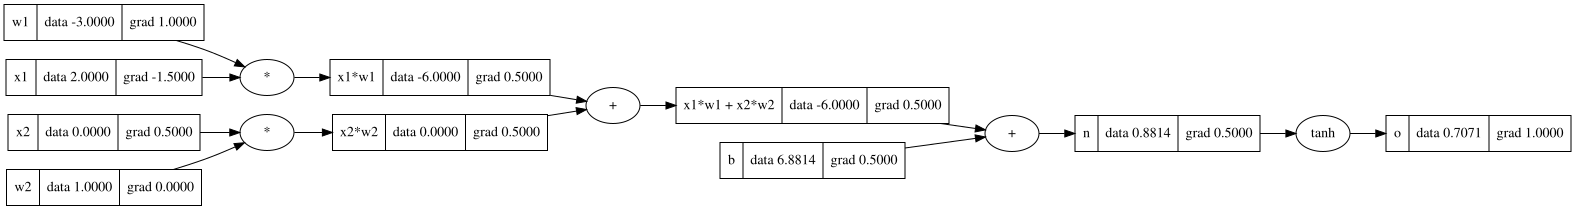

In [ ]:
draw_dot(o)

### 3.3 · Gradyan birikimi — aynı Value birden fazla kez

İlk örnek (`b = a + a`)

In [ ]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
print(f"b = a + a  ->  b.data = {b.data}")
print(f"a.grad = {a.grad}   (beklenen 2.0)")
print()

a = Value(3.0, label='a')
b = Value(-2.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
print(f"f = (a*b) * (a+b)  ->  f.data = {f.data}")
print(f"a.grad = {a.grad}   (beklenen -8.0)")
print(f"b.grad = {b.grad}   (beklenen -3.0)")

b = a + a  ->  b.data = 6.0
a.grad = 2.0   (beklenen 2.0)

f = (a*b) * (a+b)  ->  f.data = -6.0
a.grad = -8.0   (beklenen -8.0)
b.grad = -3.0   (beklenen -3.0)


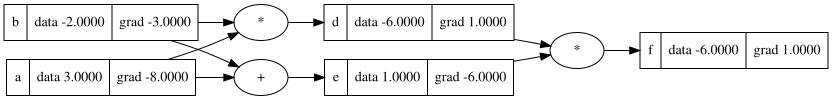

In [ ]:
draw_dot(f)   # a kutusundan iki ok çıktığına dikkat et

**Bug'ı canlı görmek (isteğe bağlı):** `+=` yerine `=` kullanan bozuk bir sürüm
`a.grad = 1.0` verir, doğrusu `2.0`'dir.

---

# Görev 4 — `tanh`'ı parçala ve üç yöntemle doğrula

> *tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster.
> Sonra doğrula: aynı ifadeyi hem backward() ile, hem numerical derivative ile, hem de PyTorch
> ile hesapla, üçünün eşleştiğini göster.* — video 1:27:05 – 1:43:55



In [ ]:
import math

class Value:


    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "şimdilik sadece int/float üs"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad     # d/dx e^x = e^x = out.data
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1
        for v in reversed(topo):
            v._backward()


    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

### 4.2 · `tanh`'ı parçala

`tanh(n) = (e^{2n} − 1) / (e^{2n} + 1)`

Grafik çok daha uzun olacak ama yaprak gradyanları **birebir aynı** çıkmalı.
Dersin asıl mesajı bu: bir kutunun yerel türevini yazabildiğin sürece,
onu tek düğüm saymak da parçalara ayırmak da senin tercihindir.

In [ ]:
# --- parçalanmış tanh ---
x1 = Value(2.0); x2 = Value(0.0)
w1 = Value(-3.0); w2 = Value(1.0)
b = Value(6.8813735870195432)

n = x1*w1 + x2*w2 + b
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.backward()
mine = {'x1': x1.grad, 'x2': x2.grad, 'w1': w1.grad, 'w2': w2.grad, 'b': b.grad}
print("parçalanmış  o =", o.data)
print(mine)

# --- atomik tanh ---
x1_ = Value(2.0); x2_ = Value(0.0); w1_ = Value(-3.0); w2_ = Value(1.0)
b_  = Value(6.8813735870195432)
o_ = (x1_*w1_ + x2_*w2_ + b_).tanh()
o_.backward()
atomic = {'x1': x1_.grad, 'x2': x2_.grad, 'w1': w1_.grad, 'w2': w2_.grad, 'b': b_.grad}
print()
print("atomik       o =", o_.data)
print(atomic)

parçalanmış  o = 0.7071067811865477
{'x1': -1.5, 'x2': 0.5, 'w1': 1.0, 'w2': 0.0, 'b': 0.5}

atomik       o = 0.7071067811865476
{'x1': -1.4999999999999996, 'x2': 0.4999999999999999, 'w1': 0.9999999999999998, 'w2': 0.0, 'b': 0.4999999999999999}


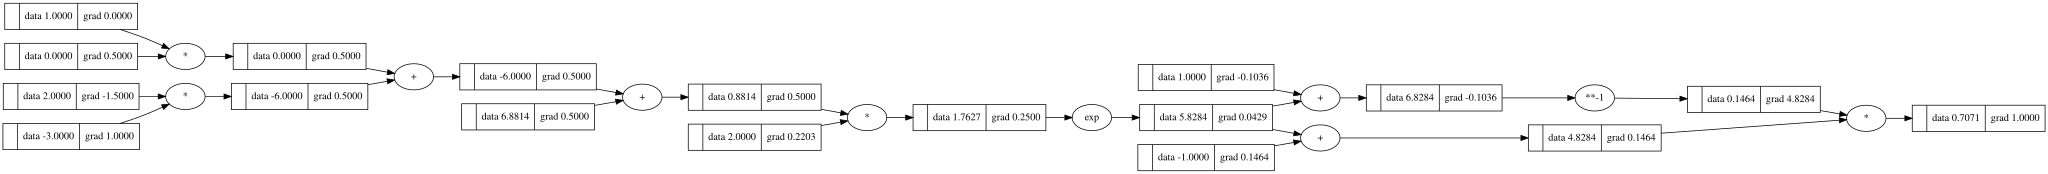

In [ ]:
draw_dot(o)

### 4.3 · Sayısal türev

Geçen haftaki yöntem: her değişkeni tek tek `h` kadar dürt, çıktının değişimini `h`'ye böl.
Sonuç **yaklaşıktır** — `h` sonlu olduğu için son basamaklarda sapma olacak.

In [ ]:
h = 1e-6

def f(x1, x2, w1, w2, b):
    return math.tanh(x1*w1 + x2*w2 + b)

p = dict(x1=2.0, x2=0.0, w1=-3.0, w2=1.0, b=6.8813735870195432)
base = f(**p)

numer = {}
for k in p:
    q = dict(p); q[k] += h
    numer[k] = (f(**q) - base) / h

print(numer)

{'x1': -1.5000031822198778, 'x2': 0.49999964635283334, 'w1': 0.9999985858266669, 'w2': 0.0, 'b': 0.49999964635283334}


### 4.4 · PyTorch



In [ ]:
import torch

t = {}
for k, v in p.items():
    t[k] = torch.Tensor([v]).double()
    t[k].requires_grad = True

to = torch.tanh(t['x1']*t['w1'] + t['x2']*t['w2'] + t['b'])
to.backward()

pt = {k: t[k].grad.item() for k in p}
print("o =", to.item())
print(pt)

o = 0.7071066904050358
{'x1': -1.5000003851533106, 'x2': 0.5000001283844369, 'w1': 1.0000002567688737, 'w2': 0.0, 'b': 0.5000001283844369}


### 4.5 · Karşılaştırma

In [ ]:
print(f"{'':4}{'mine':>13}{'atomic':>13}{'numeric':>13}{'pytorch':>13}   ok")
ok_all = True
for k in ['x1', 'x2', 'w1', 'w2', 'b']:
    row = [mine[k], atomic[k], numer[k], pt[k]]
    ok = max(row) - min(row) < 1e-5
    ok_all &= ok
    print(f"{k:4}{row[0]:13.6f}{row[1]:13.6f}{row[2]:13.6f}{row[3]:13.6f}   {'OK' if ok else 'X'}")

print()
print("Görev 4:", "engine doğru çalışıyor" if ok_all else "hata var")

             mine       atomic      numeric      pytorch   ok
x1      -1.500000    -1.500000    -1.500003    -1.500000   OK
x2       0.500000     0.500000     0.500000     0.500000   OK
w1       1.000000     1.000000     0.999999     1.000000   OK
w2       0.000000     0.000000     0.000000     0.000000   OK
b        0.500000     0.500000     0.500000     0.500000   OK

Görev 4: engine doğru çalışıyor


**Tabloyu okurken:** sayısal sütun sistematik olarak sapıyor (`x1` için −1.500003).
Diğer üçü virgülden sonra altı basamak birebir aynı. Tolerans `1e-5` seçilmesinin sebebi bu —
`1e-9` koysan motor doğru olmasına rağmen "X" görürdün. Gradient check'te tolerans seçimi
bu yüzden önemlidir.

---

## Özet

Dört görevin sonunda elinde PyTorch'la aynı gradyanları üreten, tam çalışan bir
autograd motoru var. Öğrenilen üç şey:

1. **Türev = "azıcık dürtersem ne olur?"** Sinir ağı eğitiminin tamamı bu sorunun etrafında döner.
2. **Her düğüm sadece kendi yerel türevini bilir.** Grafiğin geri kalanı hakkında hiçbir fikri yoktur.
   Geri yayılım, bu minik yerel işlemin grafik boyunca özyinelemeli tekrarından ibarettir.
3. **Soyutlama seviyesi senin tercihindir.** Yerel türevini yazabildiğin her şey bir düğüm olabilir.

**Sırada:** `Neuron`, `Layer`, `MLP` sınıfları, MSE loss ve gradyan inişiyle eğitim döngüsü
(video 1:43:55 – 2:14:03).